# 231 — −1 / 0 / +1 Segmentation clustering

Builds blobs on the canonical sample set (via `s22_build_blob_feature_matrix`), then paints each
ERSP as a -1/0/+1 segmentation map (`s23_build_minus101_feature_matrix`), and clusters.
Outputs land in `outputs/clustering/{kmeans,hierarchical}/minus101/runs/<timestamp>/`.


In [1]:
import os, sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

sys.path.insert(0, str(Path('..').resolve()))

from functions import lf_blob_clustering_config as cfg
from functions.lf_blob_metrics import s22_build_blob_feature_matrix
from functions.lf_minus101 import (
    s23_build_minus101_feature_matrix,
    q60_plot_minus101_overlays,
)
from functions import lf_cluster_run as R

SCRIPT_NAME = '231_minus101_clustering.ipynb'


## Config

In [2]:
# ── data input ───────────────────────────────
INPUT_DIR = Path(r'\\\\nasac-m2.unige.ch\\m-HumanNeuronLab\\ANALYSIS\\FLM\\Analysis_LoraFanda\\01_FBM_Analysis\\outputs\\04_ersp_LM_RAWONLY')
if not INPUT_DIR.exists():
    INPUT_DIR = Path('../01_FBM_Analysis/outputs/04_ersp_LM_RAWONLY').resolve()

# ── blob segmentation (same params as 230 so blobs are identical) ─
VALLEY_PARAMS = cfg.VALLEY_PARAMS

# ── -101 downsampling ───────────────────────
SCALE = 1.0           # 100% — full ERSP resolution painted map. Set <1 to downsample.
SCORE_MIN = None      # set a float to gate per-blob; None keeps all

# ── clustering ───────────────────────────────
KMEANS_K_RANGE = [10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20]
HC_METHOD      = 'average'
HC_METRIC      = 'euclidean'
RANDOM_STATE   = cfg.RANDOM_STATE

print('VALLEY_PARAMS:', VALLEY_PARAMS)
print('SCALE:', SCALE, '  KMEANS_K_RANGE:', KMEANS_K_RANGE)


VALLEY_PARAMS: {'thr_pos': 2.5, 'thr_neg': -3.5, 'delta_valley': 1.5, 'min_mean_pos': 1.75, 'max_mean_neg': -2.8000000000000003, 'max_blobs': 6, 'sign_mode': 'both'}
SCALE: 1.0   KMEANS_K_RANGE: [10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20]


## Load canonical dataset

Shared across 210/230/231/232 so cross-feature comparisons are valid.


In [3]:
# Loads ERSPs from INPUT_DIR, drops non-neural channels, applies the
# high-activity gate. Single source of truth so all four clustering
# notebooks operate on the same sample set. Cached in
# 02_FBM_Clustering/outputs/_dataset/canonical/ for fast reload.
from functions.lf_dataset import prepare_dataset, DEFAULT_CACHE_DIR

df_meta, ersp_list, X_3d = prepare_dataset(INPUT_DIR, cache_dir=DEFAULT_CACHE_DIR)
print(f'\nCanonical dataset: {len(df_meta)} samples · X_3d.shape={X_3d.shape}')
df_meta.head()


[lf_dataset cache hit] \\nasac-m2.unige.ch\m-HumanNeuronLab\ANALYSIS\FLM\Analysis_LoraFanda\02_FBM_Clustering\outputs\_dataset\canonical
  1538 samples · X_3d.shape=(1538, 129, 300)

Canonical dataset: 1538 samples · X_3d.shape=(1538, 129, 300)


,patient_id,condition,task,electrode,file_path,prop_above_pos,prop_below_neg,high_activity,sample_idx
0,EL030,audio,LM,A_L10,\\nasac-m2.unige.ch\m-HumanNeuronLab\ANALYSIS\...,0.081550,0.011783,True,0
1,EL030,audio,LM,A_L11,\\nasac-m2.unige.ch\m-HumanNeuronLab\ANALYSIS\...,0.100336,0.017183,True,1
2,EL030,audio,LM,A_L12,\\nasac-m2.unige.ch\m-HumanNeuronLab\ANALYSIS\...,0.116124,0.025995,True,2
3,EL030,audio,LM,A_L13,\\nasac-m2.unige.ch\m-HumanNeuronLab\ANALYSIS\...,0.151602,0.055633,True,3
4,EL030,audio,LM,A_L14,\\nasac-m2.unige.ch\m-HumanNeuronLab\ANALYSIS\...,0.155504,0.064031,True,4


## Build blobs on the canonical samples

Calls `s22_build_blob_feature_matrix` with the same `VALLEY_PARAMS` 230 uses — blobs are deterministic
and identical to 230's blobs. 231 doesn't depend on 230 having run first.


In [4]:
_, _, blobs_per_sample = s22_build_blob_feature_matrix(
    ersp_list=ersp_list,
    max_blobs=int(VALLEY_PARAMS['max_blobs']),
    thr_pos=float(VALLEY_PARAMS['thr_pos']),
    thr_neg=float(VALLEY_PARAMS['thr_neg']),
    delta_valley=float(VALLEY_PARAMS['delta_valley']),
    min_mean_pos=float(VALLEY_PARAMS['min_mean_pos']),
    max_mean_neg=float(VALLEY_PARAMS['max_mean_neg']),
    sign_mode=str(VALLEY_PARAMS['sign_mode']),
)
print('blobs_per_sample built:', len(blobs_per_sample))


Valley-blob feature matrix: X_blob.shape=(1538, 48) (max_blobs=6, features_per_blob=8)
blobs_per_sample built: 1538


## Build -101 feature matrix

In [5]:
X_101, ds_shape = s23_build_minus101_feature_matrix(
    ersp_list=ersp_list,
    blobs_per_sample=blobs_per_sample,
    scale=SCALE,
    score_min=SCORE_MIN,
)
print('X_101:', X_101.shape, '  ds_shape:', ds_shape)


[s23_build_minus101_feature_matrix]
  Original map : 129×300 = 38700 bins
  Downsampled  : 129×300 = 38700 features  (scale=100%)
  X_101.shape  : (1538, 38700)
  Samples with any blob activity: 1538/1538
X_101: (1538, 38700)   ds_shape: (129, 300)


## QC: painted -101 maps (sanity-check 30 random samples)

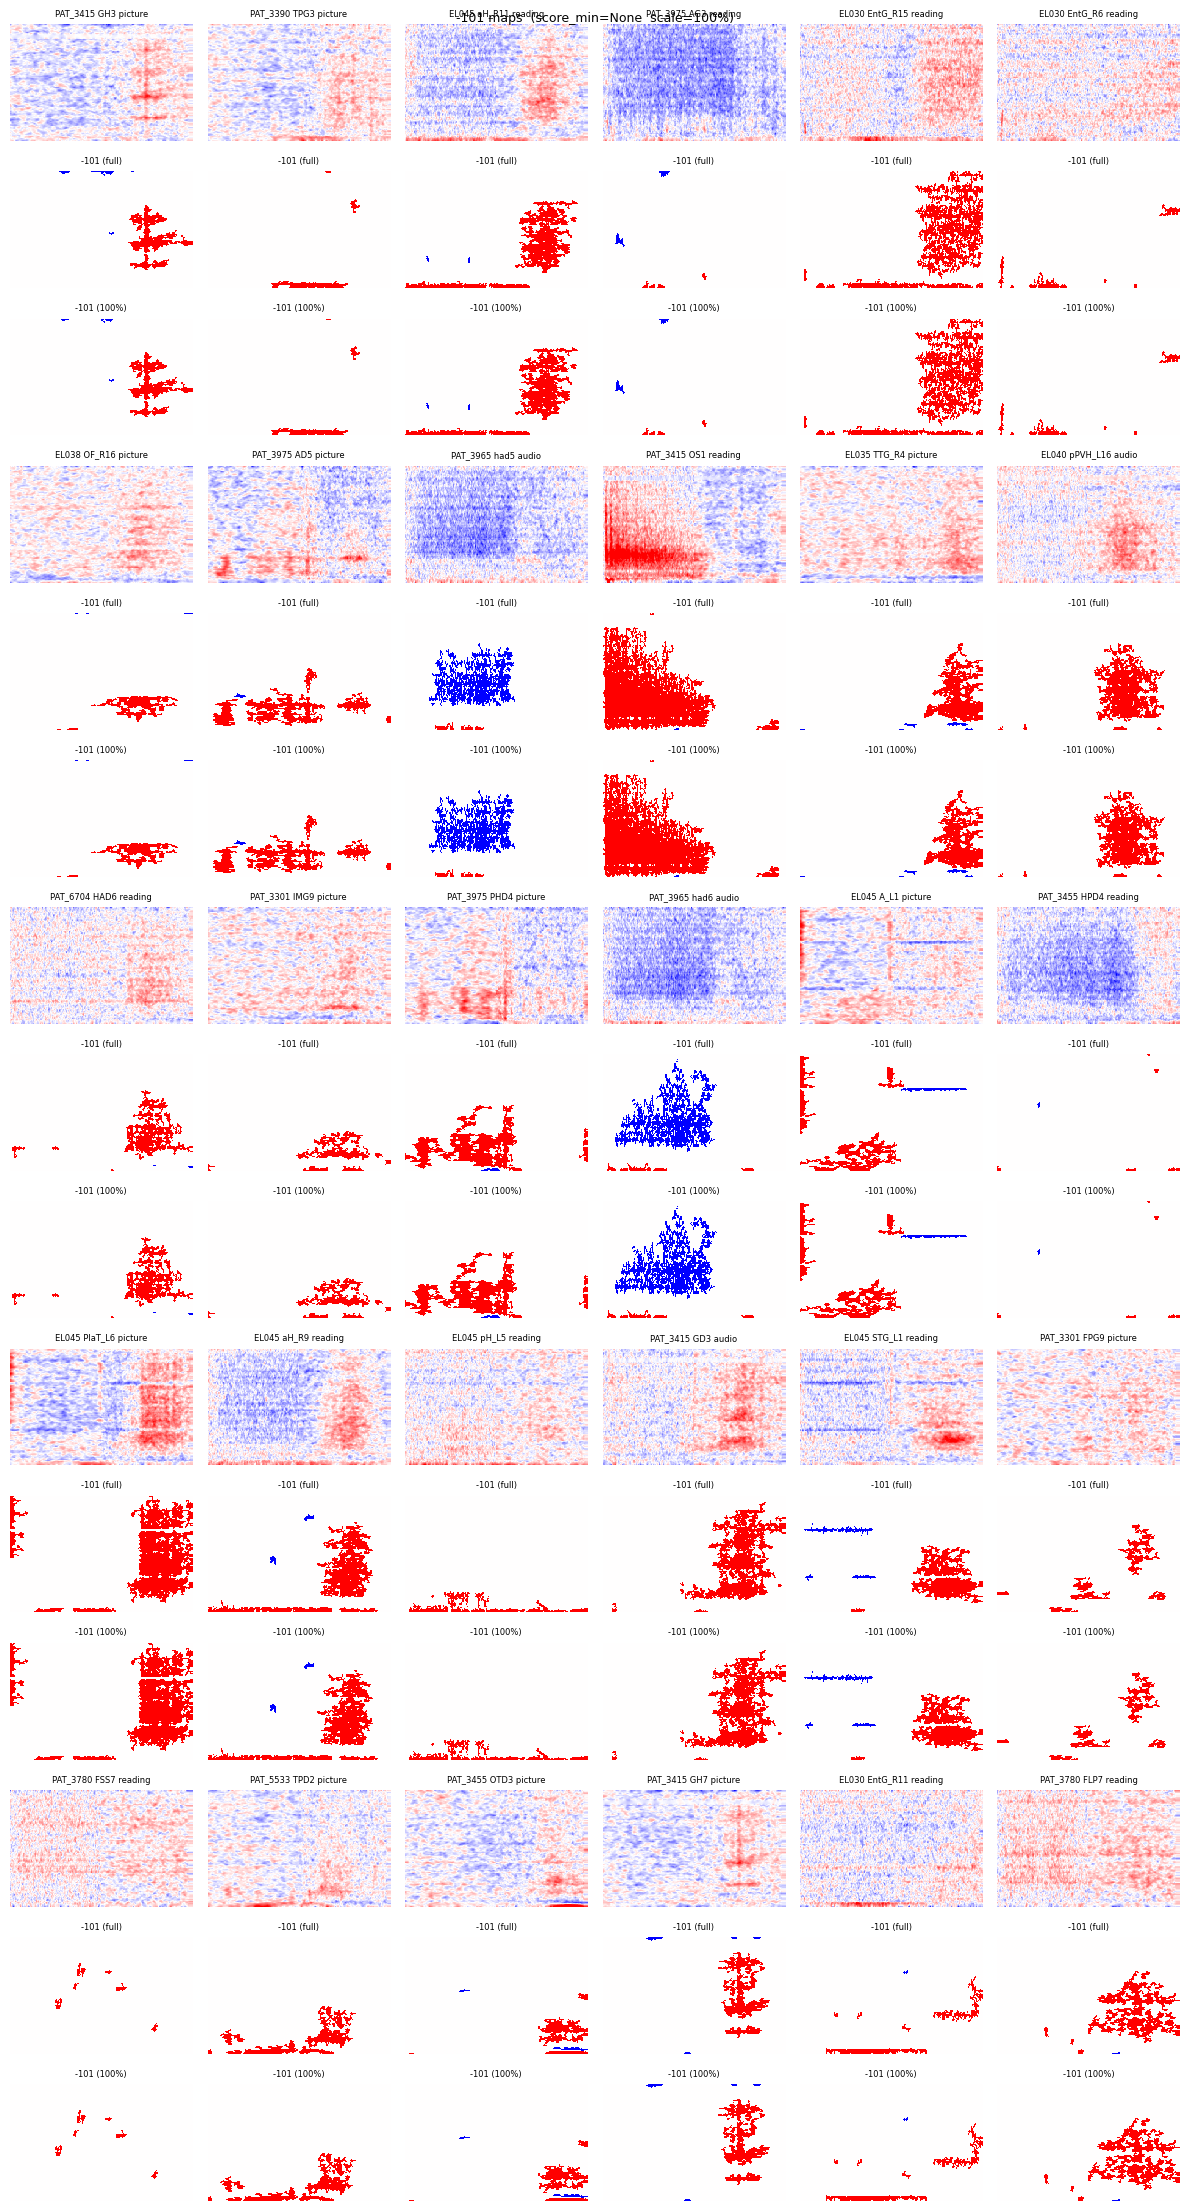

In [6]:
rng = np.random.default_rng(42)
qc_idx = rng.choice(len(ersp_list), size=min(30, len(ersp_list)), replace=False).tolist()
q60_plot_minus101_overlays(
    indices=qc_idx,
    ersp_list=ersp_list,
    blobs_per_sample=blobs_per_sample,
    df_meta=df_meta,
    scale=SCALE,
    score_min=SCORE_MIN,
)


# Clustering

In [7]:
manifest_km = R.fit_and_save(
    X_101,
    df_keep=df_meta,
    method='kmeans',
    feature_set='minus101',
    params={'k_range': KMEANS_K_RANGE, 'random_state': RANDOM_STATE, 'n_init': 20},
    method_label='K-Means',
    feature_set_label='\u22121 / 0 / +1 Segmentation',
    notebook=SCRIPT_NAME,
)
BEST_K = manifest_km['summary']['best_k']
print(f'Best K (KMeans/minus101, by silhouette): {BEST_K}')


  K= 10  sil=0.1123
  K= 11  sil=0.0451
  K= 12  sil=0.0417
  K= 13  sil=0.1186
  K= 14  sil=0.0415
  K= 15  sil=0.0863
  K= 16  sil=0.0525
  K= 17  sil=0.0469
  K= 18  sil=0.0459
  K= 19  sil=0.0439
  K= 20  sil=0.0469

[KMeans] Best K=13  silhouette=0.1186
[fit_and_save] kmeans/minus101/20260523_102735
  n_samples=1538 n_clusters=13 silhouette=0.119
  -> \\nasac-m2.unige.ch\m-HumanNeuronLab\ANALYSIS\FLM\Analysis_LoraFanda\02_FBM_Clustering\outputs\clustering\kmeans\minus101\runs\20260523_102735
Best K (KMeans/minus101, by silhouette): 13


In [8]:
manifest_hc = R.fit_and_save(
    X_101,
    df_keep=df_meta,
    method='hierarchical',
    feature_set='minus101',
    params={'linkage': HC_METHOD, 'metric': HC_METRIC, 'k_range': KMEANS_K_RANGE},
    method_label='Hierarchical',
    feature_set_label='\u22121 / 0 / +1 Segmentation',
    notebook=SCRIPT_NAME,
)
print(f'Best K (HC/minus101, by silhouette): {manifest_hc["summary"]["best_k"]}')


[HC] method=average  metric=euclidean  n=1538  cophenetic_r=0.897
  HC sweep k=10: silhouette=0.330
  HC sweep k=11: silhouette=0.320
  HC sweep k=12: silhouette=0.317
  HC sweep k=13: silhouette=0.316
  HC sweep k=14: silhouette=0.282
  HC sweep k=15: silhouette=0.275
  HC sweep k=16: silhouette=0.266
  HC sweep k=17: silhouette=0.262
  HC sweep k=18: silhouette=0.261
  HC sweep k=19: silhouette=0.254
  HC sweep k=20: silhouette=0.225
[fit_and_save] hierarchical/minus101/20260523_104339
  n_samples=1538 n_clusters=10 silhouette=0.330
  -> \\nasac-m2.unige.ch\m-HumanNeuronLab\ANALYSIS\FLM\Analysis_LoraFanda\02_FBM_Clustering\outputs\clustering\hierarchical\minus101\runs\20260523_104339
Best K (HC/minus101, by silhouette): 10


## Per-cluster centroid PNGs (for the MOBA cluster chips)

Mean -1/0/+1 map across cluster members, reshaped to `ds_shape`.


In [ ]:
import json
from pathlib import Path
from functions import lf_centroids as LC

CLUSTERING_DIR = Path(R.DEFAULT_OUTPUTS_ROOT)
INDEX_PATH = CLUSTERING_DIR / 'index.json'

# Shared centroid writer (single source of truth): writes per-K centroids
# (cluster_centroids/k_{K}/cluster_NN.png) for every K in cluster_labels_by_k.csv
# so the MOBA K slider shows the true mean of each (K, cluster) -- no
# fallback-to-best-K leakage -- plus flat best-K centroids.
#
# minus101 = 2D heatmap feature (ds_shape). X_101 is the flat (n, n_features)
# matrix row-aligned with labels.csv / cluster_labels_by_k.csv.

if INDEX_PATH.exists():
    with open(INDEX_PATH) as f:
        idx_data = json.load(f)
    runs = [r for r in idx_data.get('runs', []) if r['feature_set'] == 'minus101']
    print(f'Writing per-K + flat minus101 centroids for {len(runs)} runs...')
    for run in runs:
        mp = CLUSTERING_DIR / run['path'] / 'manifest.json'
        if not mp.exists():
            continue
        manifest = json.loads(mp.read_text())
        run_dir = CLUSTERING_DIR / run['path']
        LC.save_per_cluster_centroids(
            run_dir, X_101, feature_set='minus101', method=manifest['method'],
            centroid_shape=ds_shape, vlim=1.0,
        )
    print('Done.')
